# Common code and variables

In [45]:
%%capture
%pip install plotly pandas numpy matplotlib seaborn ipympl itables ipykernel tex latex

#  sudo apt-get install texlive  dvipng  cm-super texlive-latex-extra texlive-fonts-recommended 
# sudo apt-get -y install fonts-linuxlibertine
# sudo -H mktexlsr


In [46]:
%matplotlib widget

pathData = '/home/sandro/KIT/Messungen/Messung-Dec24/'
path = './graphs/'


import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib as mpl
# Use the pgf backend (must be set before pyplot imported)
# mpl.use('pgf')

from datetime import datetime as dt
from matplotlib import pyplot as plt, ticker
import seaborn as sns
# reset RC params to original
sns.reset_orig()
import itables as it
from itables import init_notebook_mode, show 
init_notebook_mode(all_interactive=True)

# see https://jwalton.info/Embed-Publication-Matplotlib-Latex/
width = 'acm'

plt.legend(loc='upper center')

# plt.set_dpi(100)

# Using seaborn's style
# plt.style.use('seaborn')
 
sns.color_palette("deep")
print(sns.color_palette("deep").as_hex())
print("blue orange green red")


tex_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "Times New Roman",#"serif",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 10,
    "font.size": 8,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8 
}


# plt.rcParams['text.latex.preamble'] = r'\usepackage{libertine}'
print(plt.rcParams["figure.dpi"] )


plt.rcParams.update(tex_fonts)
sns.set_theme(context="poster", style="whitegrid", rc=tex_fonts)

# some custom default setings:
scalar = 1.5
number_of_columns=3 
ratio=0.75
pagewidth_in_forDpi100=5.06
dashesReg= [(3, 3), (1, 1)]
 

<IPython.core.display.Javascript object>

['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860', '#da8bc3', '#8c8c8c', '#ccb974', '#64b5cd']
blue orange green red
100.0


In [47]:
def set_size(width, fraction=1, subplots=(1, 1)):
    """Set figure   to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Amount_of_Values of figure in inches
    """
    if width == 'thesis':
        width_pt = 426.79135
    elif width == 'beamer':
        width_pt = 307.28987
    elif width == 'acm':
        width_pt = 506.295
    else:
        width_pt = width

    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 + 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in / golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)

In [106]:

paletteDB = {'ClickHouse': '#4c72b0',
             'DataLayerTS': '#dd8452',
             'TimeScale': '#c44e52',
             'InFlux': '#55a868',
             'CH': '#4c72b0',
             'DL': '#dd8452',
             'TS': '#c44e52',
             'IF': '#55a868' }
databases_modes = {'ClickhouseDB_dedicated_regular': '#75BBA1',
                   'ClickhouseDB_dedicated_irregular': '#c77581',
                   'DatalayertsDB_dedicated_regular': '#75BDA7',
                   'DatalayertsDB_dedicated_irregular': '#75BBA1',
                   'TimescaleDB_dedicated_regular': '#c78181',
                   'TimescaleDB_dedicated_irregular': '#c78242',
                   'InfluxDB_dedicated_regular': '#8371ff',
                   'InfluxDB_dedicated_irregular': '#8381rr',
                   'PostgresDB_dedicated_regular': '#8791ff',
                   'PostgresDB_dedicated_irregular': '#8791rr',
                   'DummyDB_dedicated_regular': '#8791ff',
                   'DummyDB_dedicated_irregular': '#8791rr'}
databases_dims = {
    'ClickhouseDB_1': '#8791rr',
    'InfluxDB_1': '#8791rr',
    'DatalayertsDB_1': '#75BDA7',
    'TimescaleDB_1': '#c78181',
    'PostgresDB_1': '8791rr',
}
labels = {'ClickhouseDB': 'ClickHouse',
          'InfluxDB': 'InFlux',
          'PostgresDB': 'PostGreSQL',
          'TimescaleDB': 'TimeScale',
          'DatalayertsDB': 'DataLayerTSold',
          'DatalayertsDBasVect': 'DataLayerTS',

          }
labels_dims = {'ClickhouseDB_1': 'ClickHouse 1Dim',
               'InfluxDB': 'InfluxDB',
               'PostgresDB': 'PostgreSQL',
               'TimescaleDB': 'TimescaleDB',
               'DatalayertsDB': 'DatalayerTS',
               }
labels_modes = {'ClickhouseDB_dedicated_regular': 'ClickhouseDB_dedicated_regular',
                'ClickhouseDB_dedicated_irregular': 'ClickhouseDB_dedicated_irregular',
                'DatalayertsDB_dedicated_regular': 'DatalayertsDB_dedicated_regular',
                'DatalayertsDB_dedicated_irregular': 'DatalayertsDB_dedicated_irregular',
                'TimescaleDB_dedicated_regular': 'TimescaleDB_dedicated_regular',
                'TimescaleDB_dedicated_irregular': 'TimescaleDB_dedicated_irregular',
                'PostgresDB_dedicated_regular': 'PostgresDB_dedicated_regular',
                'PostgresDB_dedicated_irregular': 'PostgresDB_dedicated_irregular',
                'DummyDB_dedicated_regular': 'DummyDB_dedicated_regular',
                'DummyDB_dedicated_irregular': 'DummyDB_dedicated_irregular',
                'InfluxDB_dedicated_regular': 'InfluxDB_dedicated_regular',
                'InfluxDB_dedicated_irregular': 'InfluxDB_dedicated_irregular',
                }
modes = {
    'dedicated_irregular': '#f5700a',
    'dedicated_regular': '#8791ff',
    'mixed_irregular': '#75BDA7',
    'mixed_regular': '#c78181',
}
color_discrete_map_extra = {'ClickhouseDB': 'blue',
                            'TimescaleDB': 'yellow',
                            'InfluxDB': 'red',
                            'DatalayertsDB': 'green'}

colnamesRead = ['Date', 'SucceededDataPoints', 'FailedDataPoints',
                'Operation', 'Latency', 'Mode', 'System', 'ClientLatency', 'ClientsNumber', 'SensorsNumber', 'ContentStartDate',
                'Duration', 'Iteration', 'Aggregations', 'Amount_of_Values']

colnamesWrite = ['Date', 'SucceededDataPoints', 'FailedDataPoints',
                 'Operation', 'Latency', 'Mode', 'System', 'ClientLatency', 'ClientsNumber', 'SensorsNumber', 'ContentStartDate',
                 'BatchSize', 'Iteration', 'Amount_of_Values']
colnames = ['Timestamp', 'SucceededDataPoints', 'FailedDataPoints', 'Operation', 'Latency', 'Mode', 'Percentage', 'System',
            'ClientLatency', 'ClientsNumber', 'SensorsNumber', 'StartDate', 'BatchSize', 'Duration', 'Iteration', 'Aggregation', 'Amount_of_Values']


syscolnames = ['Timestamp', 'System', 'Operation', 'ClientsNumber', 'BatchSize', 'Amount_of_Values', 'Percentage', 'SensorsNumber', 'Mode', 'CpuTotal', 'CpuSystem', 'CpuUser', 'CpuIOWait', 'CpuContextSwitches', 'CpuSysCalls', 'MemActive', 'MemAvailable', 'MemBuffers', 'MemCached', 'MemFree', 'MemInActive', 'MemTotal', 'MemShared', 'MemUsed', 'SwapFree', 'SwapSin', 'SwapSout', 'SwapTotal', 'SwapUsed', 'DiskReadBytes', 'DiskReadCount', 'DiskWriteBytes',
               'DiskWriteCount', 'FsDeviceName', 'FsFree', 'FsFs_Type', 'FsKey', 'FsMnt_Point', 'FsPercent', 'FsSize', 'FsUsage', 'NetworkCumulativeConnections', 'NetworkCumulativeReceives', 'NetworkCumulativeTransmissions', 'NetworkConnections', 'NetworkTransmissions', 'NetworkReceives', 'NetworkIsUp', 'NetworkSpeed', 'ProcessCpuPercent', 'ProcessCpuTimes', 'ProcessIOCounters', 'ProcessMemoryInfo', 'ProcessMemoryPercent', 'ProcessThreadsNumber', 'ProcessStatus']


legend_kwargs = dict(borderpad=0.5, frameon=True, framealpha=1,
                     facecolor='white', edgecolor='#F5F5F5', ncol=2, title=None)

In [49]:
# System Metrics Helpers
def to_megabytes(x):
    return x / 1e6


def to_mbps(x):
    return x * 8 / 1e6


def used_mem(x):
    l = x * 100 / 32e9
    return l


def plot_database(ax, data, key, func, x=None, label=None):
    if func == 'log':
        ax.set_yscale('log')
    elif callable(func):
        data = func(data)
    if x is None:
        x = pd.Series(range(len(data)))
    return ax.plot(x, data, label=label, color=databases[key])

In [50]:
# FUNCTIONS

def _query_stat(group):
    lat = group['Latency']
    return pd.Series({'avg': lat.mean(), '50': lat.quantile(0.50), 'min': lat.min(), '20': lat.quantile(0.20), 'max': lat.max(), '70': lat.quantile(0.70),  'stddev': lat.std()})


def _query_support(col):
    return pd.Series({'support': col[col.columns[0]].count(), "CN":    col.ClientsNumber.min()})


def show_and_print_support(source, name, path, filterLowSupport, NormalizeWithCN):
    dbs = source.groupby(["System", 'Operation', 'Mode', 'BatchSize', 'ClientsNumber', 'Amount_of_Values', 'Percentage']
                         ).apply(_query_support)

    if filterLowSupport == False & NormalizeWithCN == True:
        dbs = dbs.assign(Support_CN_Normlzd=lambda x: (
            x.support / x.CN))

    if filterLowSupport == True & NormalizeWithCN == True:
        dbs = dbs.loc[dbs["Support_CN_Normlzd"] <
                      dbs["Support_CN_Normlzd"].quantile(0.25)]
    if filterLowSupport == True & NormalizeWithCN == False:
        dbs = dbs.loc[dbs["support"] < dbs["support"].quantile(0.25)]
    show_and_print(dbs, name, path)


def show_query_stat(qtype, table):
    dbs = table[table['Operation'] == qtype].groupby(
        ['Mode', "System"]).apply(_query_stat)
    show(dbs)
    print_query_stat(qtype, table, path)


def print_query_stat(qtype, table,  path):
    path = str(path)
    dbs = table[table['Operation'] == qtype].groupby(
        ['Mode', "System"]).apply(_query_stat)
    f = open(str(path)+str(qtype)+'.html', 'w')
    f.write(str(it.to_html_datatable(dbs, caption=None, connected=True)))
    f.close()


def show_and_print(content, name, path):
    name = str(name)
    path = str(path)
    show(content)
    f = open(str(path)+str(name)+'.html', 'w')
    f.write(str(it.to_html_datatable(content, caption=None, connected=True)))
    f.close()

# TODO insert older DLTS measurments and filter out that just PatchWork is kept and integrated, same for irregular ~~data~~

In [51]:
#  Loading Cleaned Data from CSV
results = [0]
 # results = pd.read_csv(
#     pathData + 'performance.csv', sep=",", on_bad_lines='warn')

# results['Timestamp'] = pd.to_datetime(
#     results['Timestamp'], unit='ms', errors='coerce')
# results['Latency'] = pd.to_numeric(results['Latency'], errors='coerce')
# results['ClientLatency'] = pd.to_numeric(
#     results['ClientLatency'], errors='coerce')
# results['BatchSize'] = pd.to_numeric(
#     results['BatchSize'], errors='coerce').fillna(0).astype(int)
# results['Amount_of_Values'] = pd.to_numeric(
#     results['Amount_of_Values'], errors='coerce')
# results['ClientsNumber'] = pd.to_numeric(
#     results['ClientsNumber'], errors='coerce')
# results['SucceededDataPoints'] = pd.to_numeric(
#     results['SucceededDataPoints'], errors='coerce')


sysdict = {'System': str, 'Operation': str, 'ClientsNumber': int,
           'BatchSize': int, 'Amount_of_Values': int, 'Percentage': int, 'SensorsNumber': int, 'Mode': str,
           'CpuTotal': float, 'CpuSystem': float, 'CpuUser': float, 'CpuIOWait': float, 'CpuContextSwitches': float,
           'CpuSysCalls': float, 'MemActive': int, 'MemAvailable': int, 'MemBuffers': int, 'MemCached': int,
           'MemFree': int, 'MemInActive': int, 'MemTotal': int, 'MemShared': int, 'MemUsed': int,
           'SwapFree': int, 'SwapSin': int, 'SwapSout': int, 'SwapTotal': int, 'SwapUsed': int,
           'DiskReadBytes': int, 'DiskReadCount': int, 'DiskWriteBytes': int, 'DiskWriteCount': int,
           'FsFree': int, 'FsPercent': float, 'FsSize': int, 'FsUsage': int,
           'NetworkCumulativeConnections': int, 'NetworkCumulativeReceives': int,
           'NetworkCumulativeTransmissions': int, 'NetworkConnections_bps': int,
           'NetworkTransmissions': int, 'NetworkReceives': int, 'NetworkIsUp': bool,
           'NetworkSpeed': int, 'ProcessCpuPercent': float, 'ProcessMemoryPercent': float,
           'ProcessThreadsNumber': int}


top_rates_raw = pd.read_csv(
    pathData + 'top_rates_raw-prepared.csv', sep=",", on_bad_lines='warn')

systemmetrics = pd.read_csv(
    pathData + 'system.csv', sep=",", on_bad_lines='warn')  # , dtype= sysdict,   na_filter= True)


systemmetrics['Timestamp'] = pd.to_datetime(
    systemmetrics['Timestamp'], unit='ms', errors='coerce')
systemmetrics['Mode'] = systemmetrics['Mode'].fillna('na')
systemmetrics['Operation'] = systemmetrics['Operation'].fillna('na')
systemmetricsDED = systemmetrics.loc[systemmetrics['Mode'].str.contains(
    'dedicated')]


cols = systemmetrics.columns.drop(
    {'Timestamp', 'System', 'Mode', 'Operation', 'NetworkIsUp'})

systemmetrics[cols] = systemmetrics[cols].apply(pd.to_numeric, errors='coerce')


results_rates = pd.read_csv(
    pathData + 'performance_rates.csv', sep=",", on_bad_lines='warn')

systemmetrics_rates = pd.read_csv(
    pathData + 'system_rates.csv', sep=",", on_bad_lines='warn')

# combinedAll = pd.read_csv(
#     pathData + 'combined_raw-prepared.csv', sep=",", on_bad_lines='warn')


combinedRates = pd.read_csv(
    pathData + 'Unified_rates.csv', sep=",", on_bad_lines='warn')












addmax=pd.read_csv(
    pathData + 'addmax.csv', sep=",", on_bad_lines='warn')
# # ServerReadings = pd.read_csv(
# #     pathData + 'ServerReadings.csv', sep=",", on_bad_lines='warn')


print(systemmetrics.dtypes)
# print(results.dtypes)
# print(top_rates_raw.dtypes)
# print(combinedRates.dtypes)

/tmp/ipykernel_571244/3159729520.py:39: DtypeWarning: Columns (44,50,51) have mixed types. Specify dtype option on import or set low_memory=False.
  systemmetrics = pd.read_csv(


Timestamp                         datetime64[ns]
IterationTimestamp                       float64
System                                    object
Operation                                 object
ClientsNumber                            float64
BatchSize                                float64
Amount_of_Values                         float64
Percentage                               float64
SensorsNumber                            float64
Mode                                      object
CpuTotal                                 float64
CpuSystem                                float64
CpuUser                                  float64
CpuIOWait                                float64
CpuContextSwitches                       float64
CpuSysCalls                              float64
MemActive                                float64
MemAvailable                             float64
MemBuffers                               float64
MemCached                                float64
MemFree             

In [52]:
# %store   result_ratesQ regularity_ingestion_results Combinded_top
# %store  labels databases   top_rates

In [53]:
# Subsets

top_rates = top_rates_raw.merge(results_rates, how='inner', on=[
    'System', 'PatchWork', 'Regularity', 'Mixed', 'Percentage', 'Operation',   'MB_per_Sec'])

top_ratesComb = top_rates_raw.merge(combinedRates, how='inner', on=[
    'System', 'PatchWork', 'Regularity', 'Mixed', 'Percentage', 'Operation',   'MB_per_Sec'])


top_rates_Ded_Ing = top_rates[top_rates['Mode'].str.contains(
    'dedicated') & top_rates['Operation'].str.contains('Ing')]

top_rates_Ded_Reg_Ing = top_rates_Ded_Ing[top_rates_Ded_Ing['Regularity'] == "regular"]

top_rates_Ded_Cons_Ing = top_rates_Ded_Ing[top_rates_Ded_Ing['PatchWork'] == False]
top_rates_Ded_Patch_Ing = top_rates_Ded_Ing[top_rates_Ded_Ing['PatchWork'] == True]

results_ratesI = results_rates.loc[results_rates['Operation'].str.contains(
    'Ingestion')].loc[results_rates["BatchSize"] > 0]
results_ratesQ = results_rates.loc[results_rates['Operation'].str.contains(
    'Quer')]
results_ratesQ_Ded = results_ratesQ.loc[results_ratesQ['Mode'].str.contains(
    'dedicated')]

# create Subtable
regularity_ingestion_results = results_rates.loc[(results_rates.Mode.str.contains(
    'dedicated_')) & (results_rates.Operation.str.contains(
        'Ingestion'))]
regularity_ingestion_results['Regularity'] = regularity_ingestion_results['Regularity'].map(
    {True: "regular", False: "irregular"})

regularity_ingestion_1V_results = regularity_ingestion_results.loc[
    regularity_ingestion_results["Amount_of_Values"] == 1]
# regularity_ingestion_results = regularity_ingestion_results.loc[regularity_ingestion_results.System.str.contains(
#     'Dummy') == False]


Combinded = pd.merge(systemmetrics_rates, results_rates, how="outer", on=[
                     'System', 'Mode', 'Operation', 'ClientsNumber', 'BatchSize', 'Amount_of_Values', 'Mixed', 'IsAggregation', 'Regularity']).assign(SystemModes=lambda x: x.System+", "+x.Mode)

Combinded = Combinded.assign(
    NetworkCompressionQuotient=lambda x: x.NetworkConnections_bps*0.001*0.001/x.MB_per_Sec*8)
Combinded = Combinded.assign(
    NetworkCompressionQuotient_Client=lambda x: x.NetworkConnections_bps*0.001*0.001/x.MB_per_Sec_with_Client*8)


Combinded_top = top_rates.merge(Combinded, how='inner', on=[
    'System', 'Mode', 'Operation', 'BatchSize', 'ClientsNumber', 'Amount_of_Values'])

Combinded_top['Operation'] = Combinded_top['Operation'].fillna('na')
Combinded_top_ingestion = Combinded_top.loc[Combinded_top.Operation.str.contains(
    "Ingest")]
Combinded['Operation'] = Combinded['Operation'].fillna('na')
Combinded["Regularity"]=Combinded["Regularity"].map({1:"regular",0:"irregular"})
Combinded_ingestion = Combinded.loc[Combinded.Operation.str.contains("Ingest")]



combinedQ_DED = results_ratesQ.merge(systemmetricsDED, how='inner', on=[
    'System', 'Mode', 'Operation', 'ClientsNumber', 'Amount_of_Values'])

/tmp/ipykernel_571244/4218182791.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regularity_ingestion_results['Regularity'] = regularity_ingestion_results['Regularity'].map(


# storage

In [54]:

# plt.close()
# # defaultxlabelfontsize=plt.rcParams['xtick.labelsize']  
# # plt.rcParams['xtick.labelsize'] = 8

# c=systemmetrics.loc[systemmetrics["Mode"].str.contains("pop") & systemmetrics["System"].str.contains("Click")  ].assign(Storage=lambda x: x.FsSize - (x.FsFree+34000000000))
# c= c.cumsum(axis=["Timestamp"])
# t=systemmetrics.loc[systemmetrics["Mode"].str.contains("pop") & systemmetrics["System"].str.contains("Ti")  ].assign(Sent_Data=lambda x: x.Timestamp.cumsum() ).assign(Storage=lambda x: x.FsSize -x.FsFree)
# d=systemmetrics.loc[systemmetrics["Mode"].str.contains("pop") & systemmetrics["System"].str.contains("In")  ].assign(Sent_Data=lambda x: x.Timestamp.cumsum() ).assign(Storage=lambda x: x.FsSize -x.FsFree)
# i=systemmetrics.loc[systemmetrics["Mode"].str.contains("pop") & systemmetrics["System"].str.contains("Da")  ].assign(Sent_Data=lambda x: x.Timestamp.cumsum() ).assign(Storage=lambda x:x.FsSize - x.FsFree)


 
# sto = sns.relplot(data= c.combine(d,t,i).rename(columns={"Sent_Data": "Sent Data","Storage":"Storage Consumption in MB"})  , kind="line",
#                                   x="Sent Data", y="", hue="System" ,palette=paletteDB,
#                                             legend=None   , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio         )
# sto.set(ylim=(0,100), autoscale_on=True, autoscaley_on=True, ylabel="MB Per Seconds, 128 Clients", xlabel="Lenght Of TS Per Sensor" )
# plt.xscale('linear')
# plt.xticks( )
# plt.yscale('linear')
# plt.yticks([0, 25, 50, 75, 100, 125])
# plt.gcf().autofmt_xdate(bottom=0.4, rotation=45)
# # sns.move_legend(Lenght_128C_1_24V, loc='upper center', bbox_to_anchor=( 0.65, 0.9), ncol=2, title=None, frameon=True,)
# plt.savefig(path+'!(C128)!vectorlenght-linesmooth_AoV1-24-015,01.svg',
#             format='svg', bbox_inches="tight")

# plt.show()
# plt.close()
# plt.close()



In [55]:


# pd.DataFrame.to_csv(ServerReadings, pathData+'ServerReadings.csv',
#                     sep=',',  index=False)


# populatedCombined_raw = pd.merge(results.loc[results.Mode.str.contains("populate_Day+0_regular")], systemmetrics.loc[systemmetrics.Mode.str.contains("pop")], how='inner', on=['IterationTimestamp','System', 'Amount_of_Values', "Regularity", "Mode"])
# pd.DataFrame.to_csv(populatedCombined_raw, pathData+'populatedCombined_raw.csv',
#                      sep=',',  index=False)


# plt.gca()
# sns.set_theme("poster",style="whitegrid")

# sns.catplot(data=populatedCombined_raw.loc[populatedCombined_raw.Mode.str.contains("pop") & populatedCombined_raw.Amount_of_Values.isin([1,24])].groupby("System","Amount_of_Values",'Regularity').max("IterationTimestamp").assign(SeriesType_with_Amount_of_Values_per_DP= lambda x:   x.Regularity.map({True:"reg. TS", False:"irreg. TS"}) + " with " + x.Amount_of_Values +" V" )
#             , kind='bar', x="SeriesType_with_Amount_of_Values_per_DP", y="FSUsage", hue="System",
#             # palette={"regular": "b", "irregular": ".85"}
#              )
# plt.yscale('linear')
# plt.savefig(path+'storage-bar-000,1.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

# show_and_print(ServerReadings, 'ServerReadings', path)

# Ingestion Scenarios


## ingestion rate 


### regular vs irregular: 

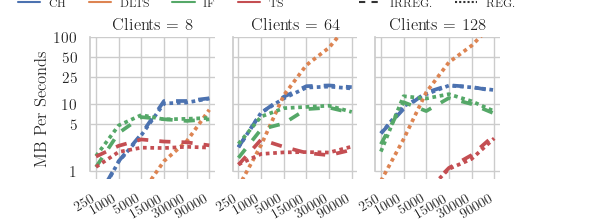

In [56]:
# 2 bs cn lineplots
plt.close()
plt.close()
sns.set_theme(style="whitegrid", rc={"font.family": "Times New Roman"})
# plt.rcParams['font.family'] = 'Times New Roman'
number_of_columns=3
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['xtick.labelsize'] = 10
reg_BS_CN_Ing_1V = sns.relplot(data=regularity_ingestion_1V_results.loc[regularity_ingestion_1V_results.ClientsNumber.isin([8,   64, 128])].replace({"BatchSize": {250: 1, 1000: 2, 5000: 3, 15000: 4, 30000: 5, 90000: 6}}).rename(columns={"ClientsNumber":"Clients"}),  x="BatchSize", y="MB_per_Sec", hue="System", style="Regularity",  linestyle='dashdot', kind="line", col="Clients", errorbar=("ci", 0.0001), dashes=dashesReg, palette=paletteDB,
                               linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio   )

reg_BS_CN_Ing_1V._legend.texts[0].set_text("") 
reg_BS_CN_Ing_1V._legend.texts[1].set_text("CH") 
reg_BS_CN_Ing_1V._legend.texts[2].set_text("DLTS") 
reg_BS_CN_Ing_1V._legend.texts[3].set_text("IF") 
reg_BS_CN_Ing_1V._legend.texts[4].set_text("TS") # removes legend title"syste,""
reg_BS_CN_Ing_1V._legend.texts[5].set_text("")  
reg_BS_CN_Ing_1V._legend.texts[6].set_text("IRREG.") 
reg_BS_CN_Ing_1V._legend.texts[7].set_text("REG.") # &"regularity"
reg_BS_CN_Ing_1V.set(ylim=(0.75, 50), ylabel=("MB Per Seconds"), xlabel="Batch Size")
 

sns.move_legend(reg_BS_CN_Ing_1V, loc='upper center', bbox_to_anchor=(
    0.39, 1.05), ncol=9, title=None, frameon=False, labelspacing=0)
plt.xticks([1, 2, 3, 4, 5, 6], [250, 1000, 5000, 15000, 30000, 90000])
plt.yscale('log')
plt.yticks([1,5,10,25,50,100],[1,5,10,25,50,100])

sns.despine(top=True, bottom=True, trim=True)
plt.gcf().autofmt_xdate(rotation=30)
 

plt.savefig(path+'!!regularityBS-CN-line-010.svg',
            format='svg', bbox_inches="tight")

plt.show()
plt.close()
plt.rcParams['legend.fontsize'] = 8

## lenght

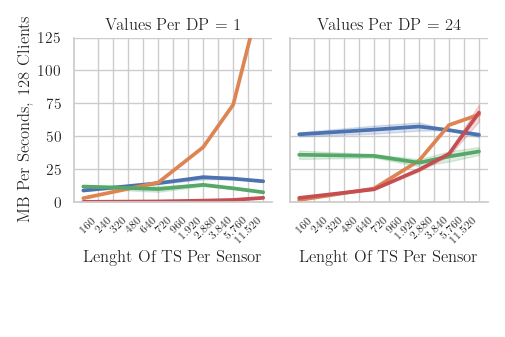

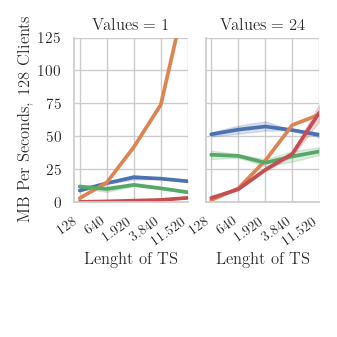

In [57]:

number_of_columns=2 

# 


plt.close()
defaultxlabelfontsize=plt.rcParams['xtick.labelsize']  
plt.rcParams['xtick.labelsize'] = 8

df=regularity_ingestion_results.loc[regularity_ingestion_results["ClientsNumber"].isin([128]) ].loc[regularity_ingestion_results["Amount_of_Values"].isin([1, 24])].assign(Lenght_of_Time_Series=lambda x: x.BatchSize / (1000 / x.ClientsNumber))
Lenght_128C_1_24V = sns.relplot(data=df.loc[df.Lenght_of_Time_Series.isin([128,160, 240, 320, 480, 640, 720, 960, 1920, 2880, 3840, 5760, 11520])].replace({"Lenght_of_Time_Series": {0.25: 0, 1: 1, 2: 2, 5: 3, 8: 4, 15: 5, 16: 6, 30: 7, 32: 8, 40: 9, 64: 10, 90: 11, 120: 12, 128: 13, 160: 14, 240: 15, 320: 16, 480: 17, 640: 18, 720: 19, 960: 20, 1920: 21, 2880: 22, 3840: 23, 5760: 24, 11520: 25}}).rename(columns={"Amount_of_Values": "Values Per DP"})  , kind="line",
                                  x="Lenght_of_Time_Series", y="MB_per_Sec", hue="System",  col="Values Per DP",palette=paletteDB,
                                            legend=None   , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio         )
Lenght_128C_1_24V.set(ylim=(0,100), autoscale_on=True, autoscaley_on=True, ylabel="MB Per Seconds, 128 Clients", xlabel="Lenght Of TS Per Sensor" )
plt.xscale('linear')
plt.xticks([  14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25], [
             160, 240, 320, 480, 640, 720, 960, "1.920", "2.880", "3.840", "5.760", "11.520"])
plt.yscale('linear')
plt.yticks([0, 25, 50, 75, 100, 125])
plt.gcf().autofmt_xdate(bottom=0.4, rotation=45)
# sns.move_legend(Lenght_128C_1_24V, loc='upper center', bbox_to_anchor=( 0.65, 0.9), ncol=2, title=None, frameon=True,)
plt.savefig(path+'!(C128)!vectorlenght-linesmooth_AoV1-24-015,01.svg',
            format='svg', bbox_inches="tight")

plt.show()
plt.close()
plt.close()



plt.close()
defaultxlabelfontsize=plt.rcParams['xtick.labelsize']  
plt.rcParams['xtick.labelsize'] = 10
ratiolocal= 0.5
number_of_columns_local=3
df=regularity_ingestion_results.loc[regularity_ingestion_results["ClientsNumber"].isin([128]) ].loc[regularity_ingestion_results["Amount_of_Values"].isin([1, 24])].assign(Lenght_of_Time_Series=lambda x: x.BatchSize / (1000 / x.ClientsNumber))
Lenght_128C_1_24V = sns.relplot(data=df.loc[df.Lenght_of_Time_Series.isin([128,160, 240, 320, 480, 640, 720, 960, 1920, 2880, 3840, 5760, 11520])].replace({"Lenght_of_Time_Series": {0.25: 0, 1: 1, 2: 2, 5: 3, 8: 4, 15: 5, 16: 6, 30: 7, 32: 8, 40: 9, 64: 10, 90: 11, 120: 12, 128: 13, 160: 0.14, 240: 0.15, 320: 0.16, 480: 0.17, 640: 14, 720: 0.19, 960: 0.20, 1920: 15, 2880: 0.22, 3840: 16, 5760: 0.24, 11520: 17}}).rename(columns={"Amount_of_Values": "Values"})  , kind="line",
                                  x="Lenght_of_Time_Series", y="MB_per_Sec", hue="System",  col="Values",palette=paletteDB,
                                            legend=None   , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal         )
Lenght_128C_1_24V.set(ylim=(0,100),xlim=(13,17), autoscale_on=True, autoscaley_on=True, ylabel="MB Per Seconds, 128 Clients", xlabel="Lenght of TS" )
plt.xscale('linear')
plt.xlim(12.8,17)
plt.xticks([  13,  14, 15,  16,  17], [
              128, 640,  "1.920", "3.840", "11.520"])
plt.yscale('linear')
plt.yticks([0, 25, 50, 75, 100, 125])
plt.gcf().autofmt_xdate(bottom=0.4, rotation=35)
# sns.move_legend(Lenght_128C_1_24V, loc='upper center', bbox_to_anchor=( 0.65, 0.9), ncol=2, title=None, frameon=True,)
plt.savefig(path+'!(C128)!vectorlenght-linesmooth_AoV1-24-SHORT-015,02.svg',
            format='svg', bbox_inches="tight")

plt.show()
plt.close()
plt.close()


## top ing and query comp


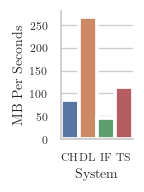

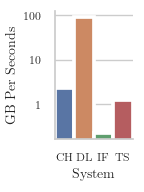

In [121]:
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['axes.labelsize'] = 10
ratio=0.75
number_of_columns=3.5
top_rates_temp = results_rates.loc[results_rates.Mode.str.contains("ded") & ((results_rates.Operation.str.contains(
    
    "RangeQueryRaw") | results_rates.Operation.str.contains("Ing")))].groupby(['System',  'Operation'], as_index=False)['MB_per_Sec'].max()

sns.catplot(data=top_rates_temp.loc[top_rates_temp.Operation.str.contains("Ing")].replace({"Regularity": {True: 'regular', False: "irregular"},"PatchWork":{True:"PatchWork", False:"Consecutive"}, "System":{"ClickHouse":"CH","InFlux":"IF","TimeScale":"TS","DataLayerTS":"DL"}}), kind='bar', x="System",palette=paletteDB,
            y="MB_per_Sec",              hue="System",errorbar=None
      ,width=1      , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio , dodge=False     )
plt.yscale('linear')
plt.ylabel('MB Per Seconds')
plt.xticks([0,1,2,3],["CH"," DL","IF","TS"])

# plt.gcf().autofmt_xdate(rotation=45)
plt.yticks([0,  50,  100, 150,200,250])
plt.savefig(path+'Top-Q_IO-bar-016,1.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()

tq=sns.catplot(data=top_rates_temp.loc[top_rates_temp.Operation.str.contains("RangeQueryRaw")].assign(GB_per_Sec=lambda x:x.MB_per_Sec/1000).replace({"Regularity": {True: 'regular', False: "irregular"},"PatchWork":{True:"PatchWork", False:"Consecutive"}, "System":{"ClickHouse":"CH","InFlux":"IF","TimeScale":"TS","DataLayerTS":"DL"}}), kind='bar', x="System", errorbar=None,
            y="GB_per_Sec",     palette=paletteDB,       hue="System"
         ,width=1    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio    , dodge=False )
plt.yscale('log')
plt.ylabel('GB Per Seconds')
plt.xticks([0,1,2,3],["CH"," DL","IF","TS"])
plt.yticks([1,10,100],[1,10,100])
# plt.gcf().autofmt_xdate(rotation=45)
plt.savefig(path+'Top-I_IO-bar-016,2.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()


## Consecutive Ingestion vs Patchwork Ingestion
### ( all parralel Clients send 1 min. batches containing all sensor data and timestamps of all batches are seemlessly attached to another - vs - Clients Send Batches where sensorsdata is distributed across clients and each bach starts the series in another point in time. )



# TODO fitler out old DLTS patchWork records (maybe at that thime they have not been called patchwork) and insert them

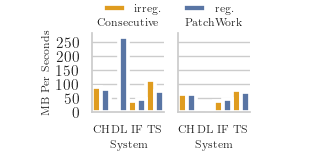

In [59]:
#  TOP Values
ratio=0.75 
number_of_columns=4
plt.rcParams['xtick.labelsize'] = 8
 
#  ,on=['System','Mode','Operation','PatchWork','Regularity','MB_per_Sec']
datax=pd.concat([top_rates_Ded_Ing,addmax])[["System","PatchWork","MB_per_Sec","Regularity"]].reset_index()
pw=sns.catplot(data=datax.replace({"Regularity": {True: 'regular', False: "irregular"},"PatchWork":{True:"PatchWork", False:"Consecutive"}, "System":{"ClickHouse":"CH","InFlux":"IF","TimeScale":"TS","DataLayerTS":"DL"}}), kind='bar', x="System",
            y="MB_per_Sec", col="PatchWork",  
            hue="Regularity", palette={"regular": "b", "irregular": "orange"}
  ,width=1            , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio  )
plt.yscale('linear')
 
plt.subplots_adjust(hspace=0.2,wspace=0.2)
pw.set(ylabel=('MB Per Seconds'))
# plt.xticks([1,2,3,4],["CH","DL","IF","TS"])
plt.yticks([0,  50,  100, 150,200,250])
pw._legend.texts[0].set_text("irreg.")
pw._legend.texts[1].set_text("reg.")
pw.set_titles('{col_name}')
# plt.gcf().autofmt_xdate(rotation=45)
sns.move_legend(pw, loc='upper center' ,ncol=3,bbox_to_anchor=(0.5, 1.15))
# pw._legend.texts[0].set_text("") 
plt.savefig(path+'regularityTOP_withCons-bar-017.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()



### Multi Dim


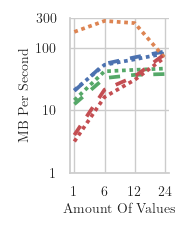

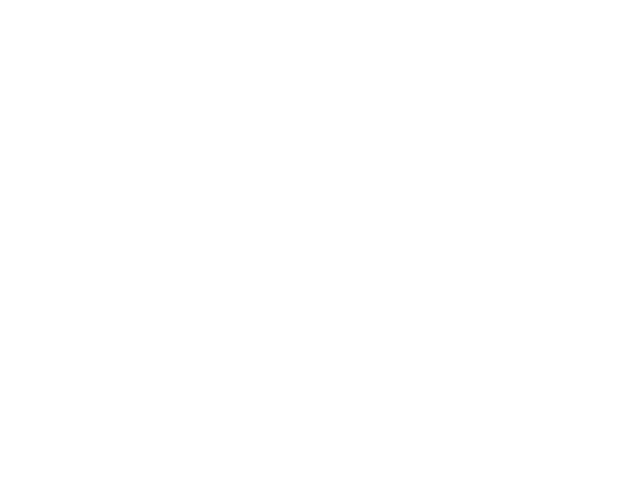

In [60]:
ratio=0.75
number_of_columns=2.5


plt.rcParams['xtick.labelsize'] = 10

plt.rcParams['ytick.labelsize'] = 10

multidimIng_TOP_all = regularity_ingestion_results.loc[regularity_ingestion_results.Mode.str.contains("ded")].groupby(['System', 'Amount_of_Values', 'Regularity'], as_index=False)[
    'MB_per_Sec'].max()

# TODO lineplot with variance  , 99% quantil . 1 % quantil or min and max ,, like a mix between barplot and lineplots

# dim   = sns.relplot(data=results_ratesI.loc[results_ratesI.Mode.str.contains("ded")], kind="line", x="Amount_of_Values",
#                         y="MB_per_Sec",   hue="System", style="Regularity" , dashes= dashesReg
#                            , errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio )
# plt.yscale('log')
# plt.xticks([1, 6, 12, 24])
# dim._legend.texts[5].set_text("")   # &"regularity"
# dim._legend.texts[6].set_text("reg. TS")
# dim._legend.texts[7].set_text("irreg. TS")
# sns.move_legend(dim, loc='center right', ncol=1, title=None, frameon=False,)
# plt.savefig(path+'!multidim-avg-Ing-line-019.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

plt.rcParams['xtick.labelsize'] = 10

plt.rcParams['ytick.labelsize'] = 10

plt.figure("multidim-line")
# dim   = sns.relplot(data=multidimIng_TOP_all.replace({"Amount_of_Values":{1:1,6:2,12:3,24:4}})
#                                                      , kind="line", x="Amount_of_Values",palette=paletteDB,
#                         y="MB_per_Sec",   hue="System", style="Regularity" , dashes= dashesReg
#                         , errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.yscale('log')
# plt.grid()

# plt.xticks([1,2,3,4],[1, 6, 12, 24])
# dim._legend.texts[0].set_text("") 
# dim._legend.texts[1].set_text("CH") 
# dim._legend.texts[2].set_text("DLTS") 
# dim._legend.texts[3].set_text("IF") 
# dim._legend.texts[4].set_text("TS") 
# dim._legend.texts[5].set_text("")   # &"regularity"
# dim._legend.texts[6].set_text("IRREG.")
# dim._legend.texts[7].set_text("REG.")
# plt.grid()
# dim.set(xlabel="Amount Of Values", ylabel="MB Per Second")
# sns.move_legend(dim, loc='upper center', ncol=11,bbox_to_anchor=(0.5, 1.2), title=None, frameon=False,)
# plt.savefig(path+'!multidim-top-Ing-line-019,1.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
plt.rcParams['xtick.labelsize'] = 8


plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.figure("multidim-line")
dim   = sns.relplot(data=multidimIng_TOP_all.replace({"Amount_of_Values":{1:1,6:2,12:3,24:4}})
                                                     , kind="line", x="Amount_of_Values",palette=paletteDB,
                        y="MB_per_Sec",   hue="System", style="Regularity" , dashes= dashesReg, legend=None
                        , errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/2.7)/0.8 , aspect=0.8)
plt.yscale('log')
plt.grid()
plt.ylim(top=300)
plt.yticks([1,10,100,300],[1,10,100,300])
plt.xticks([1,2,3,4],[1, 6, 12, 24])
# dim._legend.texts[0].set_text(" ") 
# dim._legend.texts[1].set_text("CH") 
# dim._legend.texts[2].set_text("DLTS") 
# dim._legend.texts[3].set_text("IF") 
# dim._legend.texts[4].set_text("TS") 
# dim._legend.texts[5].set_text("")   # &"regularity"
# dim._legend.texts[6].set_text("IRREG.")
# dim._legend.texts[7].set_text("REG.")
plt.grid()
dim.set(xlabel="Amount Of Values", ylabel="MB Per Second")
# sns.move_legend(dim, loc='upper center', ncol=11,bbox_to_anchor=(0.5, 1.2), title=None, frameon=False,)
plt.savefig(path+'!multidim-top-Ing-line-NOLEGEND-019,2.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()
plt.rcParams['xtick.labelsize'] = 8


# System Metrics

##  Ing System Metrics


### regurlar vs irregular transaction system usage 


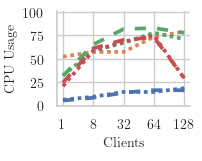

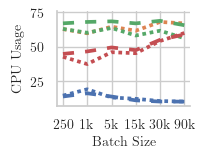

<Figure size 1159.72x869.792 with 0 Axes>

In [147]:
plt.rcParams['axes.labelsize'] = 10

number_of_columns=2.5
ratioloc=1.25
# USED
 
plt.figure("Cpu-Cn")
plt.rcParams['xtick.labelsize'] = 10
sns.relplot(data=combinedRates.loc[combinedRates["Operation"].str.contains("Ing")].replace({"ClientsNumber": {1: 0, 8: 1, 32: 2, 64: 3, 128: 4}}).rename(columns={"ClientsNumber":"Clients", "CpuTotal":"CPU Usage"}), x="Clients", y="CPU Usage", kind="line",palette=paletteDB,
             hue="System", style="Regularity", dashes=dashesReg,  legend=None,
       errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratioloc , aspect=ratioloc
             
             )
plt.ylim(top=101) 
plt.yticks([0, 25,50, 75, 100],[0, 25,50, 75, 100])
plt.grid()
# plt.legend(loc='center right', bbox_to_anchor=(1.65, 0.5))
plt.xticks([0, 1, 2, 3, 4], [1, 8, 32, 64, 128])
# plt.gcf().autofmt_xdate(rotation=45)
plt.grid()
plt.savefig(path+'!!cpu-cn-024.svg', format='svg', bbox_inches="tight")
plt.show()
plt.close()
# USED

plt.figure("Cpu-Bs")
plt.rcParams['xtick.labelsize'] = 10

sns.relplot(data=combinedRates.loc[combinedRates["Operation"].str.contains("Ing")].replace({"BatchSize": {250: 0, 1000: 1, 5000: 2, 15000: 3, 30000: 4, 90000: 5}}).rename(columns={"BatchSize":"Batch Size", "CpuTotal":"CPU Usage"}), x="Batch Size", y="CPU Usage",kind="line",palette=paletteDB,
             hue="System", style="Regularity", dashes=dashesReg,  legend=None,
          errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratioloc , aspect=ratioloc
             )
# plt.gcf().autofmt_xdate(rotation=45)
plt.grid()
plt.ylim(top=76) 
# plt.legend(loc='center right', bbox_to_anchor=(1.65, 0.5))
plt.xticks([0, 1, 2, 3, 4, 5], [250, "1k", "5k", "15k", "30k", "90k"])
plt.grid()
plt.savefig(path+'!!Cpu-Bs-025.svg', format='svg', bbox_inches="tight")
plt.show()
plt.close()
plt.rcParams['xtick.labelsize'] = 10

# USED
plt.figure("Cpu-Cn")


# sns.relplot(data=combinedRates.loc[combinedRates["Operation"].str.contains("Ing")&combinedRates.BatchSize.isin([5000,15000])].replace({"ClientsNumber": {1: 0, 8: 1, 32: 2, 64: 3, 128: 4}}).rename(columns={"ClientsNumber":"Clients", "CpuTotal":"CPU Consumption"}), x="Clients", y="CPU Consumption",palette=paletteDB,kind="line", 
#              hue="System", style="Regularity",dashes=dashesReg, legend=None,
#            errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio
#              )
# plt.xticks([0, 1, 2, 3, 4], [1, 8, 32, 64, 128])
# plt.grid()
# plt.gcf().autofmt_xdate(rotation=45)
# plt.grid()
# plt.savefig(path+'!BS5-15!cpu-cn-025,1.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# # USED

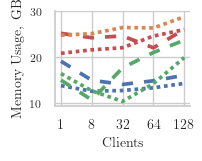

In [125]:
plt.close()
plt.close()

number_of_columns=2.5

###
 
sns.relplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")].replace({"ClientsNumber": {1: 0, 8: 1, 32: 2, 64: 3, 128: 4}}).assign(MemActiveGB=lambda x:x.MemActive/1000000000).rename(columns={"ClientsNumber":"Clients","MemActiveGB":"Memory Usage, GB"}), x="Clients", y="Memory Usage, GB",palette=paletteDB,
             hue="System", style="Regularity",    legend=None,kind="line",dashes=dashesReg,
              errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/1.25 , aspect=1.25)
# plt.legend(loc='center right', bbox_to_anchor=(1.895, 0.5))
plt.xticks([0, 1, 2, 3, 4], [1, 8, 32, 64, 128])
# plt.gcf().autofmt_xdate(rotation=45)
plt.ylim(top=30)
plt.savefig(path+'!mem-cn-026.svg', format='svg', bbox_inches="tight")
plt.show()
plt.close()

# plt.rcParams['xtick.labelsize'] = 9

# sns.relplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")].replace({"BatchSize": {250: 0, 1000: 1, 5000: 2, 15000: 3, 30000: 4, 90000: 5}}).rename(columns={"BatchSize":"Batch Size","MemActive":"Memory Consumption"}), x="Batch Size", y="Memory Consumption",palette=paletteDB,
#              hue="System", style="Regularity",    kind="line",legend=None,dashes=dashesReg,
#               errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.legend(loc='center right', bbox_to_anchor=(1.895, 0.5))
# plt.xticks([0, 1, 2, 3, 4, 5], [250, 1000, 5000, "15k", "30k", "90k"])
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'mem-Bs-027.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# plt.rcParams['xtick.labelsize'] = 10



# sns.relplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")&combinedRates.BatchSize.isin([5000,15000])].rename(columns={"ClientsNumber":"Clients","MemActive":"Memory Consumption"}), x="Clients", y="Memory Consumption",palette=paletteDB,kind="line",
#              hue="System", style="Regularity",   legend=None,dashes=dashesReg,
#               errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.legend(loc='center right', bbox_to_anchor=(1.895, 0.5))
# plt.xticks([1,8,32,64,128])
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'!BS5+15-mem-cn-027,1.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

 

In [63]:
# # Disk and swap

# number_of_columns=3

# # plt.figure("Ingestion Disk WriteCOunt ")
# sns.catplot(data=systemmetricsDED[systemmetricsDED['Operation'].str.contains(
#     "Ing")], kind="bar", x='System', palette=paletteDB,y="DiskWriteCount",
#               errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.gcf().autofmt_xdate()
# plt.yscale('log')
# plt.savefig(path+'IngWriteCount-033.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# # plt.figure("Ingestion Disk Write Bytes ")
# sns.catplot(data=systemmetricsDED[systemmetricsDED['Operation'].str.contains(
#     "Ing")], kind="bar", x='System',palette=paletteDB, y="DiskWriteBytes", hue="System",
#               errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.gcf().autofmt_xdate()
# plt.yscale('log')
# plt.savefig(path+'IngWriteBytes-034.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# # sns.relplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")], kind="line", x="ClientsNumber",
# #             y="SwapUsed", hue="System",palette=paletteDB, style="Mode",
# #               errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# # plt.yscale('log')
# # plt.savefig(path+'swap-035.svg', format='svg', bbox_inches="tight")
# # plt.show()
# # plt.close()

# ####
# sns.catplot(data=systemmetricsDED[systemmetricsDED['Operation'].str.contains(
#     "Ing")& systemmetricsDED.BatchSize.isin([5000,15000])],palette=paletteDB, kind="bar", x='System', y="DiskWriteBytes", hue="System",
#               errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.gcf().autofmt_xdate()
# plt.yscale('log')
# plt.savefig(path+'BS5+15-IngWriteBytes-035,1.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


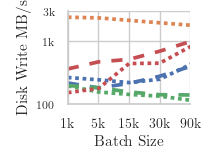

In [ ]:
number_of_columns=2
ratioold=ratio
ratio=1.25
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10
# plt.figure("Ingestion Disk Write Bytes ")
# dw=sns.catplot(data=systemmetricsDED[systemmetricsDED['Operation'].str.contains(
#     "Ing") & systemmetricsDED.ClientsNumber.isin([128]) ].assign(DMB = lambda x: x.DiskWriteBytes / 1000000).rename(columns={"DMB":"Disk Write MB/s"})
#             , kind="bar", x='System',palette=paletteDB, y="Disk Write MB/s", hue="System", legend=None,
#               errorbar=None    , linewidth=0.2  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.gcf().autofmt_xdate()
# plt.yscale('log')
# dw.set_xticklabels(["CH","IF","TS","DLTS"])
# plt.savefig(path+'IngWriteBytesC128-horiz-034,1.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
ratio=ratioold


number_of_columns=2.5
ratioold=ratio
ratio=1.25
# plt.figure("Ingestion Disk Write Bytes ")
dw=sns.relplot(data=systemmetricsDED[systemmetricsDED['Operation'].str.contains(
    "Ing") & systemmetricsDED.ClientsNumber.isin([128]) ].assign(DMB = lambda x: x.DiskWriteBytes / 1000000).rename(columns={"DMB":"Disk Write MB/s"}).replace({"BatchSize":{1000:1,5000:2,15000:3,30000:4,90000:5}})
            , x='BatchSize',palette=paletteDB, y="Disk Write MB/s", hue="System", legend=None, kind="line", style="Regularity", dashes=dashesReg,
              errorbar=None    , linewidth=4/scalar  , height=((pagewidth_in_forDpi100)/number_of_columns)/ratio , aspect=ratio)
# plt.gcf().autofmt_xdate()
plt.yscale('log')
plt.ylim(top=3000)
plt.yticks([100,1000,3000],["100","1k","3k"])
dw.set(xlim=(1,5),xticks=[1,2,3,4,5],xticklabels=["1k", "5k", "15k", "30k", "90k"],xlabel="Batch Size")
plt.savefig(path+'IngWriteBytesC128-BS-034,2.svg', format='svg', bbox_inches="tight")
plt.show()
plt.close()
ratio=ratioold

### multiDim transaction system usage

### Network Usage

In [65]:
# # Todo
# # Compare Compression Policys


# plt.figure("NW-Dim")
# plt.title("NW Dim")

# sns.lineplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")], x="Amount_of_Values", y="NetworkConnections_bps",palette=paletteDB,
#              hue="System", style="Mode", markers=True, dashes=dashesReg, errorbar=("ci",  0.0001))
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'NW-Dim-038.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

# plt.figure("NW-cn")
# plt.title("NW cn")

# sns.lineplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")], x="ClientsNumber", y="NetworkConnections_bps",palette=paletteDB,
#              hue="System", style="Mode", markers=True, dashes=dashesReg, errorbar=("ci",  0.0001))
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'NW-cn-039.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# plt.figure("NW-bs")
# plt.title("NW bs")

# sns.lineplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")], x="BatchSize", y="NetworkConnections_bps",palette=paletteDB,
#              hue="System", style="Mode", markers=True, dashes=dashesReg, errorbar=("ci",  0.0001))
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'NW-bs-040.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# # Network vs DiskIO

# # plt.figure("NW-IO")
# # plt.title("NW -IO")

# # sns.lineplot(data=systemmetricsDED.loc[systemmetricsDED["Operation"].str.contains("Ing")], x="DiskWriteBytes", y="NetworkConnections_bps",
# #              hue="System", style="Mode", markers=True, dashes=False)
# # plt.xscale("log")
# # plt.yscale("log")
# # plt.savefig(path+'NW-IO-041.svg', format='svg', bbox_inches="tight")
# # plt.show()
# # plt.close()
# # Network vs CPU

# # plt.figure("NW-CPU")
# # plt.title("NW CPU")

# # sns.lineplot(data=systemmetricsDED, x="CpuTotal", y="NetworkConnections_bps_bps",
# #              hue="System", style="Mode", markers=True, dashes=False)
# # plt.savefig(path+'NW-CPU-042.svg', format='svg', bbox_inches="tight")
# # plt.show()
# # plt.close()

In [66]:
# plt.figure("NW-CPU")
# plt.title("NW CPU")

# sns.catplot(data=systemmetricsDED,kind="point", x="NetworkConnections_bps_bps", y="CpuTotal",
#              hue="System")
# plt.savefig(path+'NW-CPU-043.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

## Combined Metrics

### Ingestion CPU vs Bandwidth


In [67]:
# # top ingestion cpu vs bandwithd
# # sns.set_theme(style="whitegrid")
# # plt.style.use('seaborn')
# plt.close()
# plt.close()
# plt.figure("CPU-vs-Bandwidth-Pair_top")
# sns.scatterplot(Combinded_top_ingestion.loc[Combinded_top_ingestion["Mode"].str.contains(
#     "dedicated_")], x="MB_per_Sec_x", y="CpuTotal",palette=paletteDB, hue="System", style="Mode", s=500)
# plt.xscale("linear")
# plt.legend(loc='center right', bbox_to_anchor=(1.9, 0.5))

# plt.savefig(path+'!CPU-vs-Bandwidth_Pair_TOP-055.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()




# plt.figure("CPU-vs-DiskWrite-Pair_top")
# sns.scatterplot(Combinded_top_ingestion.loc[Combinded_top_ingestion["Mode"].str.contains(
#     "dedicated_")], x="DiskWriteBytes", y="CpuTotal",palette=paletteDB, hue="System", style="Mode", s=500)
# plt.xscale("linear")
# plt.legend(loc='center right', bbox_to_anchor=(1.9, 0.5))

# plt.savefig(path+'!DiskWrite-vs-CPU_Pair_TOP-055,1.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# plt.close()
# plt.close()




In [68]:

# plt.figure("CPU-vs-Bandwidth-Pair_top")
# sns.relplot(combinedRates.loc[combinedRates["Mode"].str.contains(
#     "dedicated_")& combinedRates.ClientsNumber.isin([128]) & combinedRates.BatchSize.isin([15000])& combinedRates.Amount_of_Values.isin([1]) & combinedRates.PatchWork.isin([False]) ] ,kind="scatter", x="CpuTotal",y="MB_per_Sec", palette=paletteDB,hue="System", style="Regularity", s=500, legend=None)
# plt.xscale("linear")
# # plt.legend(loc='center right', bbox_to_anchor=(1.9, 0.5))

# plt.savefig(path+'!CPU-vs-Bandwidth_Pair_TOP-055,2.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()



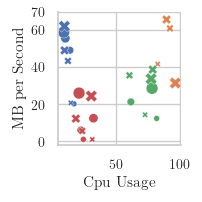

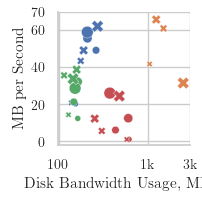

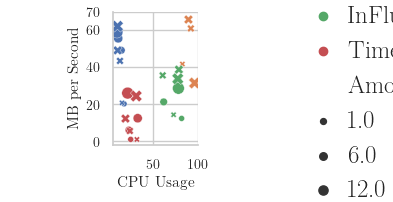

In [217]:

# plt.figure("BS5-15-CPU-vs-Bandwidth-Pair")


# sns.scatterplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")&Combinded_ingestion.BatchSize.isin([5000,15000])], x="MB_per_Sec", y="CpuTotal", hue="System", style="Mode")
# plt.xscale("log")
# plt.legend(loc='center right', bbox_to_anchor=(1.9, 0.5))

# plt.savefig(path+'!(BS5-15)_CPU-vs-Bandwidth_Pair-055,2.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# sns.set_theme(context="paper", style="whitegrid", rc=tex_fonts)

plt.rcParams['axes.labelsize'] = 11

number_of_columns_local=2
ratiolocal=1
linelocal=0.25

plt.figure("BS5-15:CPU-vs-Bandwidth_top")
iobm=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")&Combinded_ingestion.BatchSize.isin([15000]) &  Combinded_ingestion.ClientsNumber.isin([128]) ].groupby(["System", "Amount_of_Values","Regularity"], as_index=False).max({"MB_per_Sec"}).rename(columns={"CpuTotal":"Cpu Usage","MB_per_Sec":"MB per Second"}), kind="scatter", y="MB per Second", x="Cpu Usage", palette=paletteDB,hue="System", style="Regularity", size="Amount_of_Values"  ,legend=False, 
           linewidth=linelocal  , height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratio , aspect=ratiolocal)
plt.xscale("linear")
plt.yscale("linear")
plt.ylim(top=70)
plt.yticks([0,20,40,60,70],[0,20,40,60,70])
# sns.move_legend(iobm,loc='center right', bbox_to_anchor=(1.13, 0.5),  fontsize="17")#

plt.savefig(path+'!(BS15,C128)_CPU-vs-Bandwidth_DIM_Pair--055,21.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()

# , s=500


plt.figure("BS5-15:CPU-vs-Bandwidth_top")
iobm=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")&Combinded_ingestion.BatchSize.isin([15000]) &  Combinded_ingestion.ClientsNumber.isin([128]) ].groupby(["System", "Amount_of_Values","Regularity"], as_index=False).max({"MB_per_Sec"}).assign(DiskWriteMB=lambda x: x.DiskWriteBytes/1000000).rename(columns={"CpuTotal":"Cpu Usage","MB_per_Sec":"MB per Second", "DiskWriteMB":"Disk Bandwidth Usage, MB/s"}), kind="scatter", y="MB per Second", x="Disk Bandwidth Usage, MB/s", palette=paletteDB,hue="System", style="Regularity", size="Amount_of_Values" , legend=False,  
            linewidth=linelocal  , height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratio , aspect=ratiolocal)
plt.xscale("log")
plt.yscale("linear")
plt.ylim(top=70)
plt.yticks([0,20,40,60,70],[0,20,40,60,70])
plt.xlim(right=3005)
plt.xticks([100,1000,3000],[100,"1k","3k"])
# sns.move_legend(iobm,loc='center right', bbox_to_anchor=(0.95, 0.5),  fontsize="17")#

plt.savefig(path+'!(BS15,C128)_Disk-vs-Bandwidth_+DIM_Pair--055,22.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()





plt.figure("BS5-15:CPU-vs-Bandwidth_top")
iobm=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")&Combinded_ingestion.BatchSize.isin([15000]) &  Combinded_ingestion.ClientsNumber.isin([128]) ].groupby(["System", "Amount_of_Values","Regularity"], as_index=False).max({"MB_per_Sec"}).rename(columns={"CpuTotal":"CPU Usage","MB_per_Sec":"MB per Second"}), kind="scatter", y="MB per Second", x="CPU Usage", palette=paletteDB,hue="System", style="Regularity", size="Amount_of_Values"  ,legend=True, 
           linewidth=linelocal  , height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratio , aspect=ratiolocal)
plt.xscale("linear")
plt.yscale("linear")
plt.ylim(top=70)
plt.yticks([0,20,40,60,70],[0,20,40,60,70])
sns.move_legend(iobm,loc='center right', bbox_to_anchor=(1.4, .4))#,  fontsize="17"

plt.savefig(path+'!(BS15,C128)_CPU-vs-Bandwidth_DIM_Pair--055,21-LEGEND.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()

# plt.figure("BS5-15-CPU-vs-DiskWrite-Pair_top")
# sns.scatterplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")&Combinded_ingestion.BatchSize.isin([15000]) &  Combinded_ingestion.ClientsNumber.isin([128]) ], x="DiskWriteBytes", y="CpuTotal", hue="System", style="Mode", s=500)
# plt.xscale("log")
# plt.legend(loc='center right', bbox_to_anchor=(1.6, 0.5))

# plt.savefig(path+'!(BS15,C128)_DiskWrite-vs-CPU_Pair_-055,3.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

plt.rcParams['axes.labelsize'] = 10


# plt.figure("BS5-15-CPU-vs-DiskWrite-Pair_top")
# DC=sns.scatterplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")&Combinded_ingestion.BatchSize.isin([15000]) &  Combinded_ingestion.ClientsNumber.isin([128])], x="DiskWriteBytes", y="CpuTotal", palette=paletteDB,hue="System", style="Amount_of_Values", s=500)
# plt.xscale("log")
# sns.move_legend(DC,loc='center right',bbox_to_anchor=(1.65, 0.5),  fontsize="17" )

# plt.savefig(path+'!(BS15,C128)_DiskWrite-vs-CPU_Pair_-055,3.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# sns.set_theme(context="poster", style="whitegrid", rc=tex_fonts)


### Ingestion IO vs Bandwidth

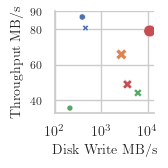

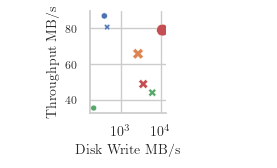

In [151]:

# plt.figure("DiskIO-vs-Bandwidth_top")
# iobm=sns.relplot(Combinded_top_ingestion.loc[Combinded_top_ingestion["Mode"].str.contains(
#     "dedicated_") ], kind="scatter", y="MB_per_Sec_x", x="DiskWriteBytes", palette=paletteDB,hue="System", style="Regularity_x", size="DiskWriteCount", )
# plt.xscale("linear")
# plt.yscale("linear")
# sns.move_legend(iobm,loc='center right', bbox_to_anchor=(1.05, 0.5) )

# plt.savefig(path+'DiskIO-C+W-vs-Bandwidth_top_C-scatter-060.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


ratiolocal=1
number_of_columns_local=3
plt.rcParams.update(tex_fonts)
plt.rcParams['xtick.labelsize'] = 10
plt.figure("BS5-15:DiskIO-vs-Bandwidth_top")
iobm=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")&Combinded_ingestion.BatchSize.isin([5000,15000]) ].groupby(["System", "Regularity"], as_index=False).max({"MB_per_Sec"}).assign(DMB = lambda x: x.DiskWriteBytes / 1000000).rename(columns={"DMB":"Disk Write MB/s","DiskWriteCount":"Disk Requests/s","MB_per_Sec":"Throughput MB/s"})
                 
                 , kind="scatter", y="Throughput MB/s", x="Disk Write MB/s", palette=paletteDB,hue="System", style="Regularity", size="Disk Requests/s",legend=None ,  height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.xscale("log")
plt.xlim(left=100)
plt.yscale("linear")
plt.ylim(top=70)
plt.yticks([40,60,80,90],[40,60,80,90])
# sns.move_legend(iobm,loc='upper center', bbox_to_anchor=( 0.5, 1), ncol=3, fontsize="17")

plt.savefig(path+'(BS5-15)DiskIO-C+W-vs-Bandwidth_C-scatter-060,1.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()
 
plt.figure("BS5-15:DiskIO-vs-Bandwidth_top")
iobm=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")&Combinded_ingestion.BatchSize.isin([5000,15000]) ].groupby(["System", "Regularity"], as_index=False).max({"MB_per_Sec"}).assign(DMB = lambda x: x.DiskWriteBytes / 1000000).rename(columns={"DMB":"Disk Write MB/s","DiskWriteCount":"Disk Requests/s","MB_per_Sec":"Throughput MB/s"})
                 
                 , kind="scatter", y="Throughput MB/s", x="Disk Write MB/s", palette=paletteDB,hue="System", style="Regularity", size="Disk Requests/s",legend=True ,  height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.xscale("log")
plt.yscale("linear")


sns.move_legend(iobm,loc='lower right', bbox_to_anchor=( 1.2, 1.2), ncol=3, fontsize="17")

plt.savefig(path+'(BS5-15)DiskIO-C+W-vs-Bandwidth_C-scatter-060,1-LEGEND.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()
 

# Ingestion Network VS Bandwidth (Compression effectiveness) 

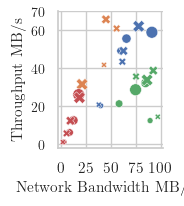

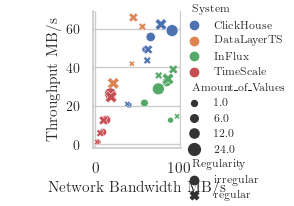

In [158]:
# plt.figure("NW-vs-Bandwidth")
# plt.title("NW-vs-Bandwidth")
# sns.lineplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")], x="MB_per_Sec", y="NetworkConnections_bps", hue="System", style="Mode")
# plt.xscale("log")
# plt.yscale("log")
# plt.legend(loc='center right', bbox_to_anchor=(1.65, 0.5))

# plt.savefig(path+'NW-vs-Bandwidth-061.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

# plt.figure("NW-vs-Bandwidth")
# plt.title("NW-vs-Bandwidth")
# sns.scatterplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")], x="MB_per_Sec_with_Client", y="NetworkConnections_bps",palette=paletteDB, hue="System", style="Mode")
# plt.xscale("log")
# plt.yscale("log")
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'NW-vs-Bandwidth-scatter-062.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 11

ratiolocal=0.89
number_of_columns_local=2.75
plt.figure("BS5-15-NW-vs-Bandwidth")
nwd=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")& Combinded_ingestion.BatchSize.isin([15000]) & Combinded_ingestion.ClientsNumber.isin([128])].groupby(["System", "Regularity", "Amount_of_Values"], as_index=False).max({"MB_per_Sec"}).assign(Network_MBpS= lambda x: x.NetworkConnections_bps/1000000), y="MB_per_Sec", kind="scatter",x="Network_MBpS",palette=paletteDB, hue="System", style="Regularity", size="Amount_of_Values", s=500,  legend=None, height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.xscale("linear")
plt.xticks([0,25,50,75,100])
plt.yscale("linear")
plt.ylim(top=70)
plt.yticks([0,20,40,60,70],[0,20,40,60,70])
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))
nwd.set(ylabel="Throughput MB/s",xlabel="Network Bandwidth MB/s    _")
figlegend= nwd.legend
plt.savefig(path+'!(BS15C128)NW-vs-Bandwidth-DIM-scatter-062,01.svg',
            format='svg', bbox_inches="tight")
plt.show()

plt.close()





plt.figure("BS5-15-NW-vs-Bandwidth")
nwd=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
    "dedicated_")& Combinded_ingestion.BatchSize.isin([15000]) & Combinded_ingestion.ClientsNumber.isin([128])].groupby(["System", "Regularity", "Amount_of_Values"], as_index=False).max({"MB_per_Sec"}).assign(Network_MBpS= lambda x: x.NetworkConnections_bps/1000000), y="MB_per_Sec", kind="scatter",x="Network_MBpS",palette=paletteDB, hue="System", style="Regularity", size="Amount_of_Values", s=500,  legend=True, height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.xscale("linear")
plt.yscale("linear")
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))
nwd.set(ylabel="Throughput MB/s",xlabel="Network Bandwidth MB/s")
figlegend= nwd.legend
plt.savefig(path+'!(BS15C128)NW-vs-Bandwidth-DIM-scatter-062,01-LEGEND.svg',
            format='svg', bbox_inches="tight")
plt.show()

plt.close()


plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 10

# plt.figure("BS5-15-NW-vs-Bandwidth")
# plt.title("NW-vs-Bandwidth")
# nw=sns.relplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")& Combinded_ingestion.BatchSize.isin([15000]) & Combinded_ingestion.ClientsNumber.isin([128])].groupby(["System", "Regularity"], as_index=False).max({"MB_per_Sec"}).assign(Network_MBpS= lambda x: x.NetworkConnections_bps/1000000), y="MB_per_Sec", x="Network_MBpS", kind="scatter",palette=paletteDB, hue="System", style="Regularity", s=500,legend=None ,  height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
# plt.xscale("linear")
# plt.yscale("linear")
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))
# nw.set(ylabel="Throughput MB/S",xlabel="Network Bandwidth MB/S")
# plt.savefig(path+'!(BS15C128)NW-vs-Bandwidth-scatter-062,1.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# plt.figure("NW-vs-Bandwidth_Client")
# plt.title("NW-vs-Bandwidth_Client")
# sns.lineplot(Combinded_ingestion.loc[Combinded_ingestion["Mode"].str.contains(
#     "dedicated_")], x="MB_per_Sec_with_Client", y="NetworkConnections_bps", hue="System", style="Mode")
# plt.xscale("log")
# plt.yscale("log")

# plt.savefig(path+'NW-vs-Bandwidth_Client-063.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

#  Ingestion Network vs CPU (Compression efficiency)

# Mixed, Online Workloads

In [86]:


mixedWL_rates = results_rates.loc[results_rates.Mode.str.contains('mix')]
mixedWL_ratesI = mixedWL_rates.loc[mixedWL_rates.Operation.str.contains('Ing')]
mixedWL_ratesQ = mixedWL_rates.loc[mixedWL_rates.Operation.str.contains('Que')]

## Ingestion

comp ded/mixed WL
ingest


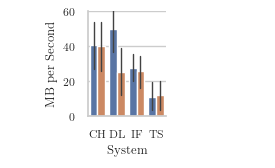

In [193]:


# print("under mixed WL")
# sns.catplot(data=mixedWL_ratesI, x="ClientsNumber", y="MB_per_Sec",  hue="System",
#             kind="bar", col="Regularity", col_wrap=2, errorbar=("ci", 95), )
# plt.yscale('linear')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")

# plt.savefig(path+'Mix-I-rates_-080.svg', format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

test= results_ratesI.loc[results_ratesI.ClientsNumber.isin([128])]
# print("comp ded/mixed WL")
# print("ingest")
# sns.catplot(data=test.loc[test.BatchSize.isin([15000.0])], x="System", y="MB_per_Sec",  hue="Mixed",
#             kind="bar", col="Regularity", col_wrap=2, errorbar=("ci", 95), )
# plt.yscale('linear')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate()

# plt.savefig(path+'(BS15,C128)Mix-I-rates_DedMix-Reg-081.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# # plt.close()

test=test.loc[test.BatchSize.isin([15000.0])& test.Regularity==True  ].rename(columns={"MB_per_Sec":"MB per Second"})
test.System=test.System.map({"DataLayerTS":"DL","InFlux":"IF","ClickHouse":"CH","TimeScale":"TS"})
ratiolocal=1
number_of_columns_local=3

plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8

ws= plt.rcParams['legend.borderaxespad']
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.borderaxespad'] = 0.2
print("comp ded/mixed WL")
print("ingest")
m811=sns.catplot(data=test, x="System", y="MB per Second",  hue="Mixed", errwidth=1,
            kind="bar" ,   height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)#, palette=paletteDB
plt.yscale('linear')
plt.ylim(top=60)
plt.yticks([0,20,40,60],[0,20,40,60])
# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
m811._legend.texts[0].set_text("dedicated workloads")
m811._legend.texts[1].set_text("mixed workloads")
sns.move_legend(m811, loc="upper center",title=None, ncol=1 , bbox_to_anchor=(0.4, 1.26), fontsize=8.5 ,frameon=True, borderpad=0.4,  handletextpad=0.4, borderaxespad=0.1, columnspacing=0)
plt.savefig(path+'!(BS15,C128,Reg)Mix-I-rates_DedMix-081,1.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()
plt.rcParams['legend.borderaxespad'] =ws
# m82=sns.catplot(data=test.loc[test.BatchSize.isin([15000.0])], x="Percentage", y="MB_per_Sec",  hue="System", col="Mixed",
#             kind="bar", palette=paletteDB,errorbar=("ci", 95), legend=False)
# plt.yscale('linear')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# # plt.gcf().autofmt_xdate()

# plt.savefig(path+'!(BS15,C128)Mix-I-rates_DedMix_Perc-line-082.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

## Query Attentions: RangeQ.:MixedQueries are Limited, Dedicated are Full

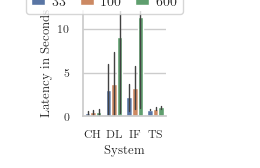

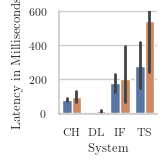

In [195]:
plt.rcParams['xtick.labelsize'] = 8


m086=sns.catplot(data=results_ratesQ.loc[results_ratesQ.Mode.str.contains('Limit') & results_ratesQ.ClientsNumber.isin([128])].assign(Latency_in_sec=lambda x: x.Latency/1000000).replace({"System":{"DataLayerTS":"DL","InFlux":"IF","ClickHouse":"CH","TimeScale":"TS"}}).rename(columns={"MB_per_Sec":"MB per Second","Latency_in_sec":"Latency in Seconds"}), x="System", y="Latency in Seconds",  hue="Percentage", errwidth=1,
            kind="bar"  ,height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal )#,palette=paletteDB, errorbar=("ci", 95),
plt.yscale('linear')
# plt.gcf().autofmt_xdate()

# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
plt.ylim(0,12)

plt.rcParams['legend.columnspacing'] = 1
plt.rcParams['legend.handletextpad'] = 0.5
plt.rcParams['legend.handlelength'] = 1
sns.move_legend(m086, loc="upper center", ncol=3 ,frameon=True, bbox_to_anchor=(0.4, 1.21), fontsize="10")

plt.savefig(path+'Mix-Q-rates_C128_DedMix_perc-086.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()


sns.catplot(data=results_ratesQ.loc[results_ratesQ.Operation.str.contains("Range") == False & results_ratesQ.ClientsNumber.isin([128])].assign(Latency_in_ms=lambda x: x.Latency/1000).replace({"System":{"DataLayerTS":"DL","InFlux":"IF","ClickHouse":"CH","TimeScale":"TS"}}).rename(columns={"MB_per_Sec":"MB per Second","Latency_in_ms":"Latency in Milliseconds"}), x="System", y="Latency in Milliseconds",  hue="Mixed", errwidth=2,
            kind="bar",  legend=False,   height=((pagewidth_in_forDpi100)/number_of_columns_local)/1.01 , aspect=1.01)#,palette=paletteDB, errorbar=("ci", 95),
plt.yscale('linear')
# plt.gcf().autofmt_xdate()
sns.despine()
plt.ylim(-5,601)

# m811._legend.texts[0].set_text("dedicated workloads")
# m811._legend.texts[1].set_text("mixed workloads")
# sns.move_legend(m811, loc="upper center",title=None, ncol=1 , bbox_to_anchor=(0.45, 1.09))
# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
plt.savefig(path+'Mix-Q-AGG_C128_DedMix-086,1.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()

plt.rcParams['xtick.labelsize'] = 8

## System Metrics

# 
#
#
#
#


In [89]:

# sns.catplot(data=systemmetrics.loc[systemmetrics.Mode.str.contains('Limit')], x="System", y="MemCached",  hue="Percentage",palette=paletteDB,
#             kind="bar", col="ClientsNumber", col_wrap=2, errorbar=("pi", 50), )
# plt.yscale('log')
# plt.gcf().autofmt_xdate(rotation=45)# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.savefig(path+'Mix-Q-sysMemCache-rates_DedMix_perc-095.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# sns.catplot(data=systemmetrics.loc[systemmetrics.Mode.str.contains('Limit')], x="System", y="MemBuffers",  hue="Percentage",palette=paletteDB,
#             kind="bar", col="ClientsNumber", col_wrap=2, errorbar=("pi", 50), )
# plt.yscale('log')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'Mix-Q-sysMemTotal-rates_DedMix_perc-096.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# print("RangeFul")
# sns.catplot(data=systemmetrics.loc[systemmetrics.Operation.str.contains('Ran') & systemmetrics.Mode.str.contains('Lim') == False], x="System",palette=paletteDB, y="MemBuffers",  hue="Mixed",
#             kind="bar", col="ClientsNumber", col_wrap=2, errorbar=("pi", 50), )
# plt.yscale('log')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'Mix-Q-sysMemTotal-rates_DedMix_CN-097.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# print("agg")
# sns.catplot(data=systemmetrics.loc[systemmetrics.Operation.str.contains('Qu') & systemmetrics.Operation.str.contains('Rang') == False], x="System", palette=paletteDB,y="MemBuffers",  hue="Mixed",
#             kind="bar", col="ClientsNumber", col_wrap=2, errorbar=("pi", 50), )
# plt.yscale('log')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'Mix-Q-sysMemTotal-rates_DedMix_CN-098.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


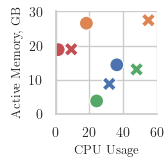

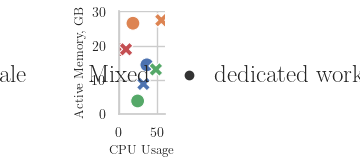

In [205]:
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.labelsize'] = 9

df=Combinded.loc[Combinded.Operation.str.contains('Q')  & Combinded.ClientsNumber.isin([128])]


number_of_columns_local=3
ratiolocal=1

mMC=sns.relplot(data=df.groupby(["System","Mixed"], as_index=False).agg({"MemActive":"mean", "CpuTotal":"mean"}).assign(Active_Memory_in_GB= lambda x: x.MemActive / 1000000000).rename(columns={"CpuTotal":"CPU Usage","Active_Memory_in_GB":"Active Memory, GB"}), x="CPU Usage", y="Active Memory, GB",  style="Mixed",   palette=paletteDB, s=100,
            kind="scatter", hue="System", legend=None,
             
               height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('linear')
plt.ylim(0,30)
plt.yticks([0,10,20,30],[0,10,20,30])
plt.xlim(0,60)
plt.xticks([0,20,40,60],[0,20,40,60])
# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)
# sns.move_legend(mMC, loc="upper center", bbox_to_anchor=(0.5,1.55), ncol=1,fontsize="17", title=None)
plt.savefig(path+'Mix-Q-sysMemCpu-rates_C128__DedMix-098,3.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()




mMC=sns.relplot(data=df.groupby(["System","Mixed"], as_index=False).agg({"MemActive":"mean", "CpuTotal":"mean"}).assign(Active_Memory_in_GB= lambda x: x.MemActive / 1000000000).rename(columns={"CpuTotal":"CPU Usage","Active_Memory_in_GB":"Active Memory, GB"}), x="CPU Usage", y="Active Memory, GB",  style="Mixed",   palette=paletteDB, s=100,
            kind="scatter", hue="System", legend=True,
             
               height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('linear')
plt.ylim(0,30)
plt.xlim(0,60)
mMC._legend.texts[6].set_text("dedicated workloads")
mMC._legend.texts[7].set_text("mixed workloads")
# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)
sns.move_legend(mMC, loc="right", bbox_to_anchor=(1.8533,0.55), ncol=8,  title=None)
plt.savefig(path+'Mix-Q-sysMemCpu-rates_C128__DedMix-098,3-LEGEND.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()



# sns.catplot(data=df.assign(Memory_Buffers_in_MB= lambda x: x.MemBuffers / 1000000), x="System", y="Memory_Buffers_in_MB",  hue="Mixed",palette=paletteDB,
#             kind="bar",   )
# plt.yscale('linear')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'Mix-Q-sysMemBuff-rates_C128__DedMix-098,1.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()
# sns.catplot(data=df, x="System", y="MemActive",  hue="Mixed",
#             kind="bar",   )
# plt.yscale('linear')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)

# plt.savefig(path+'Mix-Q-sysMemBuff-rates_C128__DedMix-098,2.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


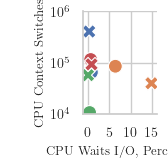

/tmp/ipykernel_571244/1825974183.py:27: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,501)
/tmp/ipykernel_571244/1825974183.py:30: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,2001)


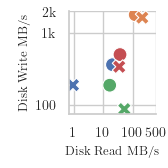

In [209]:

number_of_columns_local=3
ratiolocal=1
df=combinedRates.loc[  combinedRates.ClientsNumber.isin([128])]
plt.rcParams['axes.labelsize'] = 9
mMC=sns.relplot(data=df.groupby(["System","Mixed"], as_index=False).agg({"CpuContextSwitches":"mean", "CpuIOWait":"mean"}).rename(columns={"CpuContextSwitches":"CPU Context Switches","CpuIOWait":"CPU Waits I/O, Percent"}) , y="CPU Context Switches", x="CPU Waits I/O, Percent",  style="Mixed" ,palette=paletteDB, s= 100,
            kind="scatter", hue="System" , legend=None   ,
               height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('log')
plt.xscale('linear')
plt.xlim(-1,16)
plt.ylim(10000,1000000)
plt.xticks([0,5,10,15])
plt.xlabel("CPU Waits I/O, Percent      _")
# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)
# sns.move_legend(mMC, loc="upper center",  bbox_to_anchor=(0.5,1.545), ncol=1,fontsize="17", title=None)#
plt.savefig(path+'Mix-Switsches-IOwait-rates-098,5.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()

mMC2=sns.relplot(data=df.groupby(["System","Mixed"], as_index=False).agg({"DiskReadBytes":"mean", "DiskWriteBytes":"mean"}).assign(DiskWriteMB=lambda x: x.DiskWriteBytes/1000000).assign(DiskReadMB=lambda x: x.DiskReadBytes/1000000).rename(columns={"DiskReadMB":"Disk Read MB/s","DiskWriteMB":"Disk Write MB/s"}) , x="Disk Read MB/s", y="Disk Write MB/s",  style="Mixed" ,palette=paletteDB,
            kind="scatter", hue="System", legend=None ,  s= 100,
               height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('log')
plt.xscale('log')
plt.xlim(0,501)

plt.xticks([1,10,100,600],[1,10,100,500])
plt.ylim(0,2001)
plt.yticks([100,1000,2000],[100, "1k ", "2k "])
# plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.gcf().autofmt_xdate(rotation=45)
# sns.move_legend(mMC2, loc="upper center",  bbox_to_anchor=(0.5,1.485425), ncol=1,fontsize="17", title=None)
plt.savefig(path+'Mix-DiskReadWrite-098,6.svg',
            format='svg', bbox_inches="tight")
plt.show()
plt.close()

In [198]:
# df= Combinded.loc[Combinded.Operation.str.contains('Q') & Combinded.ClientsNumber.isin([128])]
# sns.catplot(df=test2, x="System", y="CpuTotal",  hue="Mixed",palette=paletteDB,
#             kind="bar", legend=False )
# plt.yscale('linear')
# plt.gcf().autofmt_xdate(rotation=45)

# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.savefig(path+'Mix-Q-sys-rates_C128_DedMix-087.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

# Queries 


In [199]:


# #Batchsize

# sns.catplot(data=results_ratesQ.rename(columns={"Operation": "Op."}), x="ClientsNumber", y="Latency",  hue="System",
#             kind="point", row="Op.",  errorbar=("pi", 50), col="Mode")
# plt.yscale('log')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.savefig(path+'Q_rates_reg-All-CN-104.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# sns.catplot(data=results_ratesQ.rename(columns={"IsAggregation": "QueryFamily"}), x="ClientsNumber", y="Latency",  hue="System",
#             kind="boxen", row="QueryFamily",   errorbar=("pi", 50), col="Mode")
# plt.yscale('log')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.savefig(path+'Q_rates_reg-AggIO-CN-105.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


# sns.set_theme("whitegrid")

# q106=sns.catplot(data=results_ratesQ_Ded.rename(columns={"IsAggregation": "Family"}).replace({"Aggregation Q.": "Agg.Queries"}).assign(Latency_in_ms= lambda x: x.Latency / 1000), x="System", y="Latency_in_ms",  hue="Regularity",
#             kind="bar",     errorbar=("ci", 95), row="Family")
# plt.yscale('log')
# plt.gcf().autofmt_xdate()
# q106._legend.texts[0].set_text("irregular") 
# q106._legend.texts[1].set_text("regular") 
# sns.move_legend(q106, loc="upper center",title=None, ncol=3 , bbox_to_anchor=(0.5, 1.0355))
# plt.savefig(path+'!Qded-ratesReg-AggIO-ReG-bar-106.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()


 



# sns.catplot(data=results_ratesQ.rename(columns={"IsAggregation": "Query_Type"}).replace({"Aggregation Q.": "Agg.Queries"}).assign(Mode_and_System=lambda x: x.Regularity.map({"True": "regular", "False": "irregular"})+" TS: " + x.System), x="Query_Type", y="Latency",  hue="Mode_and_System",
#             kind="bar",  errorbar=("ci", 95))
# plt.yscale('log')
# # plt.title("Comparison: Regular vs Irregular Data Querying based on Number of Clients")
# plt.savefig(path+'!QratesReg-AggIO-ReG-bar-106,1.svg',
#             format='svg', bbox_inches="tight")
# plt.show()
# plt.close()

## Multidim Query stats

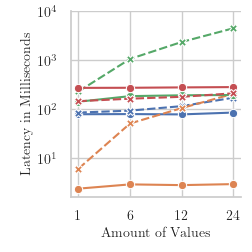

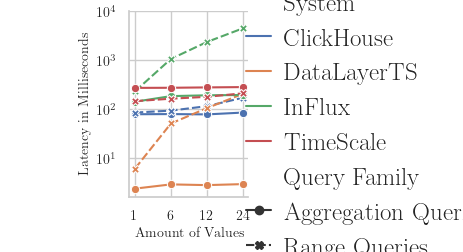

In [200]:

# plt.figure("Q-Dim-Mode")
# # plt.title("Latency across various Amount_of_Values and Modes")

# sns.lineplot(data=results_ratesQ_Ded, x="Amount_of_Values", y="Latency",  errorbar=("ci", 0.001),
#              hue="System", style="Mode", markers=True, dashes=False)
# plt.yscale('log')
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'Q-Dim-Reg-108.svg', format='svg', bbox_inches="tight")  # svg
# plt.show()
# plt.close()
number_of_columns_local=2
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.figure("Q-Dim-Mode")
q109=sns.relplot(kind="line",data=results_ratesQ_Ded.assign(Latency_in_ms=lambda x: x.Latency / 1000).replace({"Amount_of_Values":{1:1,6:2,12:3,24:4}}).rename(columns={"Amount_of_Values":"Amount of Values","Latency_in_ms":"Latency in Milliseconds"}), x="Amount of Values", y="Latency in Milliseconds", errorbar=None,palette=paletteDB,
             hue="System", style="IsAggregation", markers=True, dashes=True, legend=None,   height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('log')
plt.ylim(top=10000)
plt.xticks([1,2,3,4],[1,6,12,24])
# sns.move_legend(q109,loc='upper center', title=None, ncol=2, bbox_to_anchor=( 0.5, 1.45), fontsize="17")

plt.savefig(path+'!Q-Dim-Agg-109.svg', format='svg',
            bbox_inches="tight")  # svg
plt.show()
plt.close()

q109l=sns.relplot(kind="line",data=results_ratesQ_Ded.assign(Latency_in_ms=lambda x: x.Latency / 1000).replace({"Amount_of_Values":{1:1,6:2,12:3,24:4}}).rename(columns={"Amount_of_Values":"Amount of Values","Latency_in_ms":"Latency in Milliseconds"}), x="Amount of Values", y="Latency in Milliseconds", errorbar=None,palette=paletteDB,
             hue="System", style="IsAggregation", markers=True, dashes=True, legend=True,   height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('log')
plt.ylim(top=10000)
plt.xticks([1,2,3,4],[1,6,12,24])
plt.legend(loc='center right',bbox_to_anchor=( 0.6, 2))

q109l._legend.texts[5].set_text("Query Family")
q109l._legend.texts[6].set_text("Aggregation Queries")
q109l._legend.texts[7].set_text("Range Queries")
sns.move_legend(q109l,loc='right', title=None, ncol=1, bbox_to_anchor=( 1.1, 0.5))


plt.savefig(path+'!Q-Dim-Agg-109-LEGEND.svg', format='svg',
            bbox_inches="tight")  # svg fontsize="17"
plt.show()
plt.close()
# result_ratesQ_Ded_RegAgg = results_ratesQ_Ded.assign(RegAgg=lambda x: "Reg: "+x.Regularity.replace(
#     {True: 'True', False: 'False'}) + ", Agg: " + x.IsAggregation.replace({True: 'True', False: 'False'}))

# plt.figure("Q-Dim-Mode")
# # plt.title("Latency across various Amount_of_Values and Modes")

# sns.lineplot(data=result_ratesQ_Ded_RegAgg, x="Amount_of_Values", errorbar=("ci", 0.001),
#              y="Latency", hue="System",palette=paletteDB, style="RegAgg", markers=True, dashes=True)
# plt.yscale('log')
# plt.legend(loc='center right', bbox_to_anchor=(2.251, 0.5))

# plt.savefig(path+'Q-Dim-Reg-Agg-110.svg',
#             format='svg', bbox_inches="tight")  # svg
# plt.show()
# plt.close()

In [201]:


# plt.figure("Q-Dim-Op-A")
# # plt.title("Latency across various Amount_of_Values for RangeQueryAllDims")

# sns.lineplot(data=results_ratesQ_Ded.loc[results_ratesQ_Ded['Operation'].str.contains(
#     'RangeQueryRawAllDimsData')], x="Amount_of_Values", y="Latency", hue="System",palette=paletteDB, style="Mode", errorbar=("ci", 0.001), markers=True, dashes=True)
# plt.yscale('log')
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'Q-Dim-Alldim-111.svg',
#             format='svg', bbox_inches="tight")  # svg
# plt.show()
# plt.close()

/tmp/ipykernel_571244/1800945098.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_ratesQ_Ded2["Latency_per_Sent_Values"] = result_ratesQ_Ded2.apply(


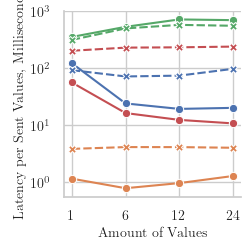

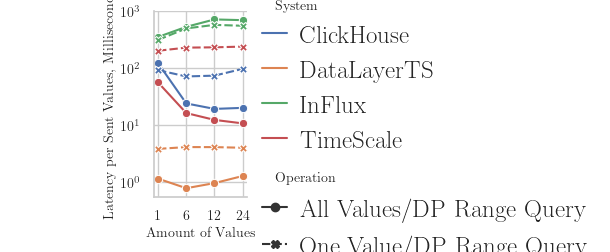

In [202]:


# plt.figure("Q-Dim-Op-1")
# # plt.title("RangeQueryRaw of 1 val. across various 'thick' tables")

# sns.lineplot(data=results_ratesQ_Ded.loc[results_ratesQ_Ded['Operation'].str.contains(
#     'RangeQueryRawData')], x="Amount_of_Values", y="Latency", hue="System", style="Mode", markers=True,  errorbar=("ci", 0.01), dashes=False)
# plt.yscale('log')
# plt.legend(loc='center right', bbox_to_anchor=(1.865, 0.5))

# plt.savefig(path+'Q-Dim-oneDim-112.svg',
#             format='svg', bbox_inches="tight")  # svg
# plt.show()
# plt.close()
# plt.close()
# plt.figure("Q-Dim-Op-1-AGG-mb")
# sns.lineplot(data=results_ratesQ_Ded.loc[results_ratesQ_Ded['Operation'].str.contains('RangeQueryRawData') | results_ratesQ_Ded['Operation'].str.contains(
#     'AllDim')], x="Amount_of_Values", y="MB_per_Sec", hue="System", errorbar=("ci", 0.01), style="Operation", markers=True, dashes=False)
# plt.yscale('log')
# plt.legend(loc='center right', bbox_to_anchor=(2.15, 0.5))

# plt.savefig(path+'!Q-Dim-oneorallDim-MB-113.svg',
#             format='svg', bbox_inches="tight")  # svg
# plt.show()
# plt.close()
# plt.close()
# plt.close()
# plt.figure("Q-Dim-Op-1-AGG-lat")
# # plt.title("RangeQueryRaw ")

# sns.lineplot(data=results_ratesQ_Ded.loc[results_ratesQ_Ded['Operation'].str.contains('RangeQueryRawData') | results_ratesQ_Ded['Operation'].str.contains(
#     'AllDim')], x="Amount_of_Values", y="Latency", hue="System", errorbar=("ci", 0.01), style="Operation", markers=True, dashes=False)
# plt.yscale('log')
# plt.legend(loc='center right', bbox_to_anchor=(2.15, 0.5))

# plt.savefig(path+'Q-Dim-oneorallDim-114.svg',
#             format='svg', bbox_inches="tight")  # svg
# plt.show()
# plt.close()

number_of_columns_local=2
ratiolocal=1

plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.figure("Q-Dim-Op-1-AGG-lin")
result_ratesQ_Ded2 = results_ratesQ_Ded
# result_ratesQ_Ded2["Latency_per_Sent_Values"]=result_ratesQ_Ded2.apply( lambda x: x.Latency/x.Amount_of_Values if x.Operation.str.contains('AllDim')==True else  x.Latency )
result_ratesQ_Ded2["Latency_per_Sent_Values"] = result_ratesQ_Ded2.apply(
    lambda row: row.Latency/row.Amount_of_Values if 'AllDim' in row['Operation'] else row.Latency, axis=1)

# is it faster to retrieve data singularly or as groupt values, in variously thick groups
q115=sns.relplot(kind="line",data=result_ratesQ_Ded2.loc[result_ratesQ_Ded2['Operation'].str.contains('RangeQueryRawData') | result_ratesQ_Ded2['Operation'].str.contains(
    'AllDim')].loc[result_ratesQ_Ded2['Mode'].str.contains('_reg')].assign(Latency_per_Sent_Values_in_ms= lambda x: x.Latency_per_Sent_Values/1000).replace({"Amount_of_Values":{1:1,6:2,12:3,24:4}}).rename(columns={"Amount_of_Values":"Amount of Values","Latency_per_Sent_Values_in_ms":"Latency per Sent Values, Milliseconds"})
             , x="Amount of Values", y="Latency per Sent Values, Milliseconds", hue="System",palette=paletteDB, errorbar=None, style="Operation", markers=True, dashes=True, legend=None  ,  height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('log')

# sns.move_legend(q115,loc='upper center',title=None , frameon=False,ncol=1, bbox_to_anchor=(  0.5, 1.82), fontsize="17")

plt.xticks([1,2,3,4],[1, 6, 12, 24])
plt.savefig(path+'!Q-Dim-oneorallDim-latPval-115.svg',
            format='svg', bbox_inches="tight")  # svg
plt.show()
plt.close()



q115=sns.relplot(kind="line",data=result_ratesQ_Ded2.loc[result_ratesQ_Ded2['Operation'].str.contains('RangeQueryRawData') | result_ratesQ_Ded2['Operation'].str.contains(
    'AllDim')].loc[result_ratesQ_Ded2['Mode'].str.contains('_reg')].assign(Latency_per_Sent_Values_in_ms= lambda x: x.Latency_per_Sent_Values/1000).replace({"Amount_of_Values":{1:1,6:2,12:3,24:4}}).rename(columns={"Amount_of_Values":"Amount of Values","Latency_per_Sent_Values_in_ms":"Latency per Sent Values, Milliseconds"})
             , x="Amount of Values", y="Latency per Sent Values, Milliseconds", hue="System",palette=paletteDB, errorbar=None, style="Operation", markers=True, dashes=True, legend=True  ,  height=((pagewidth_in_forDpi100)/number_of_columns_local)/ratiolocal , aspect=ratiolocal)
plt.yscale('log')

# sns.move_legend(q115,loc='upper center',title=None , frameon=False,ncol=1, bbox_to_anchor=(  0.5, 1.82), fontsize="17")
q115._legend.texts[6].set_text("All Values/DP Range Query")
q115._legend.texts[7].set_text("One Value/DP Range Query")
plt.xticks([1,2,3,4],[1, 6, 12, 24])
plt.savefig(path+'!Q-Dim-oneorallDim-latPval-115-LEGEND.svg',
            format='svg', bbox_inches="tight")  # svg
plt.show()
plt.close()

